# SimPEG FDEM forward modeling of a vertical thin sheet

Same model and survey as the IE run: 10 ohm-m whole space, sheet at x = 500 m (200 x 200 m, conductance ~1e4 S), VMD at the origin, 201 receivers at z = 0.75 m, 20 kHz. Three conductivity models on one octree mesh (conductive / zero-contrast / background); secondary = total(k) - total(background), reported total = analytic primary + numerical secondary. Outputs: `h-field-simpeg-*-20kHz.dat`.

Note: at 20 kHz the sheet sits at ~45 skin depths, so its true secondary (~1e-25 A/m) is far below the double-precision floor of any volumetric solver; the differenced secondary here is the numerical floor, not the sheet response. Totals are accurate out to the trusted window printed below.

In [1]:
import gc
import time
import warnings
import numpy as np
import pandas as pd

from discretize import TreeMesh
try:
    from simpeg import maps
    from simpeg.electromagnetics import frequency_domain as fdem
except ImportError:                          # older installs
    from SimPEG import maps
    from SimPEG.electromagnetics import frequency_domain as fdem
from scipy.constants import mu_0


def _pick_solver():
    '''Import alone is not enough (Pardiso/Mumps import fine but fail at use when
    pydiso / python-mumps is absent) -- test-factorize a tiny matrix.'''
    import scipy.sparse as sp
    A = sp.identity(4, format="csr") * 2.0
    try:
        import pymatsolver
        for name in ("Pardiso", "Mumps"):
            cls = getattr(pymatsolver, name, None)
            if cls is None:
                continue
            try:
                cls(A) * np.ones(4)
                return cls, f"pymatsolver.{name}"
            except Exception:
                continue
    except ImportError:
        pass
    try:
        from simpeg import SolverLU
    except ImportError:
        from SimPEG import SolverLU
    return SolverLU, "SolverLU (scipy splu -- slow; install python-mumps or pydiso)"


Solver, solver_name = _pick_solver()
print("Using solver:", solver_name)

Using solver: pymatsolver.Mumps


In [2]:
frequency  = 20.0e3
sigma_host = 1.0 / 10.0                     # 10 ohm-m whole space

MU0_F  = 4.0e-7 * np.pi                     # exactly as in WSHEET20.F
EPS0_F = 8.85419e-12                        # exactly as in WSHEET20.F
eps_host = 10.0 * EPS0_F                    # analytic primary only

# sheet: plane x = 500, y in [-100, 100], z in [-200, 0] (verified vs the IE ts_grid)
sheet_cx, sheet_cy, sheet_cz = 500.0, 0.0, -100.0
sheet_strike_extent = 200.0                 # along y
sheet_dip_extent    = 200.0                 # along z
true_thickness      = 0.1                   # m

tau_conductive   = (1.0/1.0e-5 - sigma_host) * true_thickness      # ~ +1.0e4  S
tau_zerocontrast = (1.0/10.000001 - sigma_host) * true_thickness   # ~ -1.0e-9 S
print(f"tau (scenario 1) = {tau_conductive:+.6e} S")
print(f"tau (scenario 2) = {tau_zerocontrast:+.6e} S")

src_loc = np.array([0.0, 0.0, 0.0])
moment  = 1.0
n_rx    = 201
rx_x    = np.linspace(0.0, 1000.0, n_rx)
rx_z    = 0.75
rx_loc  = np.column_stack([rx_x, np.zeros(n_rx), np.full(n_rx, rx_z)])

skin_depth = np.sqrt(2.0 / (2*np.pi*frequency * mu_0 * sigma_host))
print(f"skin depth {skin_depth:.2f} m; sheet at {500.0/skin_depth:.1f} skin depths")

tau (scenario 1) = +9.999990e+03 S
tau (scenario 2) = -9.999999e-10 S
skin depth 11.25 m; sheet at 44.4 skin depths


Analytic whole-space VMD field (e^{+i omega t}, same convention as SimPEG and WSHEET)

In [3]:
def analytic_H_zdipole(rx_xyz, freq, src=src_loc, sigma=sigma_host,
                       eps=eps_host, m=moment):
    om = 2*np.pi*freq
    k  = np.sqrt(-1j*om*MU0_F*(sigma + 1j*om*eps))
    if k.imag > 0:
        k = -k                               # decaying root: Im(k) < 0
    dx = rx_xyz[:, 0] - src[0]
    dy = rx_xyz[:, 1] - src[1]
    dz = rx_xyz[:, 2] - src[2]
    rr2 = dx**2 + dy**2 + dz**2
    rr  = np.sqrt(rr2)
    ikr = 1j*k*rr
    e   = np.exp(-ikr)
    fac_xy = 3.0*(1.0 + ikr) + ikr**2
    Hx = (m/(4*np.pi)) * e * dx*dz / rr**5 * fac_xy
    Hy = (m/(4*np.pi)) * e * dy*dz / rr**5 * fac_xy
    Hz = (m/(4*np.pi)) * e / rr**5 * (
            (3*dz**2 - rr2)*(1.0 + ikr) + (dz**2 - rr2)*ikr**2)
    return Hx, Hy, Hz

# static-limit self-test
_H = analytic_H_zdipole(np.array([[30.0, 0.0, 0.75]]), 1e-6)
_r2 = 30.0**2 + 0.75**2
_Hz_static = (moment/(4*np.pi)) * (3*0.75**2 - _r2) / _r2**2.5
assert abs(_H[2][0] - _Hz_static)/abs(_Hz_static) < 1e-6
print("analytic dipole static-limit self-test passed")

analytic dipole static-limit self-test passed


Octree mesh, geometric refinement only (refine_ball / refine_box -- function-based refine() tests cell centers and can silently miss thin regions). 2 m cells at the source, 4 m corridor along the profile, 16 m receiver tube; the 0.1 m sheet becomes a conductance-equivalent slab one 4 m cell thick (sigma_slab = sigma_host + tau/t_slab, snapped to cell boundaries) with 4 m cells over the whole sheet plane and 8/16/32 m halos. RESOLUTION = 'FULL' halves all sizes for a workstation.

In [4]:
RESOLUTION = "CONTAINER"          # "CONTAINER" (small machine) or "FULL" (workstation)

MESH_SETTINGS = {
    "CONTAINER": dict(
        dh=2.0, slab_t=4.0,
        balls=[(12.0, 2.0), (40.0, 4.0), (64.0, 8.0)],
        boxes=[((-20.0, -14.0, -18.0), (264.0, 14.0, 32.0),  4.0),   # corridor
               ((264.0, -16.0, -16.0), (1016.0, 16.0, 16.0), 16.0),  # rest of rx line
               ((496.0, -104.0, -204.0), (504.0, 104.0, 4.0),  4.0), # slab column (refined)
               ((490.0, -108.0, -208.0), (510.0, 108.0, 8.0),  8.0), # shell
               ((460.0, -140.0, -240.0), (540.0, 140.0, 40.0), 16.0),
               ((400.0, -200.0, -300.0), (620.0, 200.0, 100.0), 32.0)]),
    "FULL": dict(
        dh=1.0, slab_t=2.0,
        balls=[(12.0, 1.0), (40.0, 2.0), (90.0, 4.0), (160.0, 8.0)],
        boxes=[((-24.0, -16.0, -20.0), (320.0, 16.0, 36.0),  2.0),
               ((320.0, -16.0, -16.0), (1016.0, 16.0, 16.0), 16.0),
               ((497.0, -104.0, -204.0), (503.0, 104.0, 4.0),  2.0),
               ((492.0, -108.0, -210.0), (508.0, 108.0, 10.0), 4.0),
               ((460.0, -140.0, -240.0), (540.0, 140.0, 40.0), 16.0),
               ((400.0, -200.0, -300.0), (620.0, 200.0, 100.0), 32.0)]),
}

DOMAIN_N_BASE = 1024      # base cells per axis (power of two); domain = n_base * dh


def build_mesh(settings=None, verbose=True):
    s = settings or MESH_SETTINGS[RESOLUTION]
    dh, slab_t = s["dh"], s["slab_t"]
    n_base = DOMAIN_N_BASE
    # align: anchors = slab lower face (x), sheet edge (y), sheet bottom (z)
    slab_x0 = sheet_cx - slab_t/2.0
    centre  = np.array([250.0, 0.0, -100.0])
    anchors = np.array([slab_x0, sheet_cy - sheet_strike_extent/2.0,
                        sheet_cz - sheet_dip_extent/2.0])
    centre  = anchors + np.round((centre - anchors)/dh)*dh
    mesh = TreeMesh([[(dh, n_base)]]*3, origin=centre - n_base*dh/2.0,
                    diagonal_balance=True)
    lv = lambda cs: mesh.max_level - int(round(np.log2(cs/dh)))
    for radius, cs in s["balls"]:
        mesh.refine_ball(src_loc, radius, lv(cs), finalize=False)
    for lo, hi, cs in s["boxes"]:
        mesh.refine_box(np.asarray(lo), np.asarray(hi), lv(cs), finalize=False)
    mesh.finalize()
    if verbose:
        print(f"base {dh:g} m x {n_base} ({n_base*dh:g} m domain) | "
              f"{mesh.nC:,} cells, {mesh.n_faces:,} faces")
    return mesh, slab_t


def build_models(mesh, slab_t, dh):
    '''Three conductivity models on ONE mesh; slab box snapped to cell boundaries
    extent-preservingly, sigma_slab recomputed from the snapped thickness so the
    meshed excess conductance is exactly tau.'''
    o = mesh.origin

    def snap_span(lo, hi, axis):
        span = max(dh, round((hi - lo)/dh)*dh)
        lo_s = o[axis] + np.floor((lo - o[axis])/dh + 0.5)*dh
        return lo_s, lo_s + span

    xmin, xmax = snap_span(sheet_cx - slab_t/2, sheet_cx + slab_t/2, 0)
    ymin, ymax = snap_span(sheet_cy - sheet_strike_extent/2,
                           sheet_cy + sheet_strike_extent/2, 1)
    zmin, zmax = snap_span(sheet_cz - sheet_dip_extent/2,
                           sheet_cz + sheet_dip_extent/2, 2)
    t_eff = xmax - xmin
    cc = mesh.cell_centers
    mask = ((cc[:, 0] > xmin) & (cc[:, 0] < xmax)
            & (cc[:, 1] > ymin) & (cc[:, 1] < ymax)
            & (cc[:, 2] > zmin) & (cc[:, 2] < zmax))

    m_bg   = sigma_host*np.ones(mesh.nC)                 # scenario 3
    m_zero = m_bg.copy()                                 # scenario 2
    m_zero[mask] = sigma_host + tau_zerocontrast/t_eff
    m_cond = m_bg.copy()                                 # scenario 1
    m_cond[mask] = sigma_host + tau_conductive/t_eff

    print(f"slab (snapped): x [{xmin:g}, {xmax:g}] ({t_eff:g} m thick), "
          f"y [{ymin:g}, {ymax:g}], z [{zmin:g}, {zmax:g}]  |  {mask.sum():,} cells")
    print(f"sigma_slab: scenario 1 = {sigma_host + tau_conductive/t_eff:.4e} S/m, "
          f"scenario 2 = {sigma_host + tau_zerocontrast/t_eff:.12e} S/m")
    if zmax > rx_z:
        warnings.warn("slab top is above the receiver plane -- check alignment!")
    return {"background": m_bg, "zerocontrast": m_zero, "conductive": m_cond}

In [5]:
def build_survey():
    rx_list = [fdem.receivers.PointMagneticFluxDensity(rx_loc, orientation=o, component=c)
               for o in ("x", "y", "z") for c in ("real", "imag")]
    src = fdem.sources.MagDipole(rx_list, frequency=frequency, location=src_loc,
                                 orientation="z", moment=moment)
    return fdem.Survey([src])


def to_H(d):
    Hx = (d[0*n_rx:1*n_rx] + 1j*d[1*n_rx:2*n_rx]) / mu_0
    Hy = (d[2*n_rx:3*n_rx] + 1j*d[3*n_rx:4*n_rx]) / mu_0
    Hz = (d[4*n_rx:5*n_rx] + 1j*d[5*n_rx:6*n_rx]) / mu_0
    return Hx, Hy, Hz


mesh, slab_t = build_mesh()
models = build_models(mesh, slab_t, MESH_SETTINGS[RESOLUTION]["dh"])
survey = build_survey()


base 2 m x 1024 (2048 m domain) | 44,724 cells, 125,010 faces
slab (snapped): x [498, 502] (4 m thick), y [-100, 100], z [-200, 0]  |  2,500 cells
sigma_slab: scenario 1 = 2.5001e+03 S/m, scenario 2 = 9.999999975000e-02 S/m


Model and mesh, y = 0 cross-sections

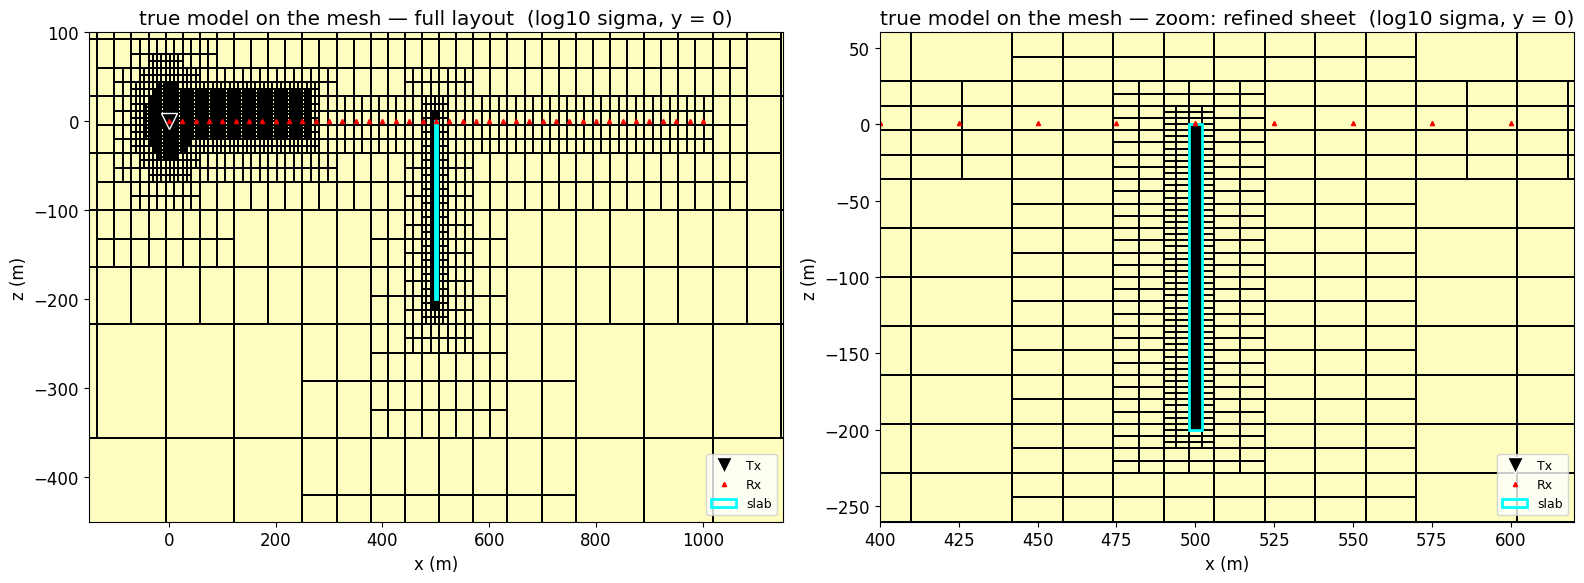

In [6]:
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 12})

sigma_true = models["conductive"]
ind_y0 = int(np.argmin(np.abs(mesh.cell_centers_y - 0.0)))

# snapped slab box for the outline (recompute exactly as build_models does)
_dh = MESH_SETTINGS[RESOLUTION]["dh"]
def _snap(lo, hi, axis):
    span = max(_dh, round((hi - lo)/_dh)*_dh)
    lo_s = mesh.origin[axis] + np.floor((lo - mesh.origin[axis])/_dh + 0.5)*_dh
    return lo_s, lo_s + span
sxmin, sxmax = _snap(sheet_cx - slab_t/2, sheet_cx + slab_t/2, 0)
szmin, szmax = _snap(sheet_cz - sheet_dip_extent/2, sheet_cz + sheet_dip_extent/2, 2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (x0, x1, z0, z1), ttl in [
        (axes[0], (-150, 1150, -450, 100), "full layout"),
        (axes[1], (400, 620, -260, 60),    "zoom: refined sheet")]:
    mesh.plot_slice(np.log10(sigma_true), normal="Y", ind=ind_y0, ax=ax, grid=True,
                    pcolor_opts={"cmap": "magma_r"},
                    grid_opts={"color": "k", "alpha": 0.25, "lw": 0.3})
    ax.plot(src_loc[0], src_loc[2], "kv", ms=12, mec="white", label="Tx")
    ax.plot(rx_loc[::5, 0], rx_loc[::5, 2], "r^", ms=3, label="Rx")
    ax.add_patch(plt.Rectangle((sxmin, szmin), sxmax - sxmin, szmax - szmin,
                               fill=False, edgecolor="cyan", lw=2, label="slab"))
    ax.set_xlim(x0, x1); ax.set_ylim(z0, z1)
    ax.set_xlabel("x (m)"); ax.set_ylabel("z (m)")
    ax.set_title(f"true model on the mesh — {ttl}  (log10 sigma, y = 0)")
    ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

In [7]:
H_num = {}
for name in ("background", "zerocontrast", "conductive"):
    sim = fdem.simulation.Simulation3DMagneticFluxDensity(
        mesh, survey=survey, sigmaMap=maps.IdentityMap(mesh), solver=Solver)
    t0 = time.time()
    d = sim.dpred(models[name])
    print(f"scenario '{name}': solved in {time.time()-t0:6.1f} s")
    H_num[name] = to_H(d)
    del sim
    gc.collect()

# secondary = total(k) - total(background), on the same mesh
Hbg = H_num["background"]
H_sec = {k: tuple(t - b for t, b in zip(H_num[k], Hbg))
         for k in ("conductive", "zerocontrast")}
H_sec["background"] = tuple(np.zeros(n_rx, complex) for _ in range(3))

# reported total = analytic primary + numerical secondary (IE-style composition)
H_pri = analytic_H_zdipole(rx_loc, frequency)
H_tot = {k: tuple(p + s for p, s in zip(H_pri, H_sec[k])) for k in H_sec}
print("secondary and total fields assembled for all three scenarios")

scenario 'background': solved in  135.9 s


scenario 'zerocontrast': solved in  115.3 s


scenario 'conductive': solved in  120.8 s


secondary and total fields assembled for all three scenarios


Checks: background vs analytic (trusted window), Hy symmetry, secondary scales

In [8]:
Hana = H_pri
Hnum = H_num["background"]
ratio = np.full(n_rx, np.nan + 1j*np.nan, complex)
nz = np.abs(Hana[2]) > 0
ratio[nz] = Hnum[2][nz] / Hana[2][nz]
amp, dph = np.abs(ratio), np.degrees(np.angle(ratio))
for lo, hi in [(5, 20), (20, 50), (50, 100), (100, 200), (200, 500), (500, 1000)]:
    sel = (rx_x >= lo) & (rx_x <= hi) & nz
    q = ratio[sel]
    print(f"x {lo:5.0f} - {hi:5.0f} m: median |ratio| {np.median(np.abs(q)):12.4e},  "
          f"median phase err {np.median(np.degrees(np.angle(q))):+8.2f} deg")

amp_med = np.array([np.nanmedian(amp[max(0, i-2):i+3]) for i in range(n_rx)])
dph_med = np.array([np.nanmedian(dph[max(0, i-2):i+3]) for i in range(n_rx)])
ok = nz & (np.abs(amp_med - 1.0) < 0.12) & (np.abs(dph_med) < 15.0)
x_edge = 1000.0
for i in range(n_rx):
    if rx_x[i] < 20.0:
        continue
    if not ok[i]:
        x_edge = rx_x[i-1]
        break
print(f"--> trusted window (rolling-median |amp-1| < 12%, |phase| < 15 deg): "
      f"x <= {x_edge:.0f} m  ({x_edge/skin_depth:.1f} skin depths)")

print()
for name in ("background", "zerocontrast", "conductive"):
    Hy = H_num[name][1]
    Hz0 = np.abs(H_num[name][2][0])
    print(f"symmetry, {name:13s}: max |Hy| = {np.abs(Hy).max():.3e} A/m "
          f"(= {np.abs(Hy).max()/Hz0:.1e} of |Hz| at the first receiver)")

print()
sec_c = np.max([np.abs(v).max() for v in H_sec["conductive"]])
sec_z = np.max([np.abs(v).max() for v in H_sec["zerocontrast"]])
print(f"max |secondary|, conductive target : {sec_c:.3e} A/m")
print(f"max |secondary|, zero contrast     : {sec_z:.3e} A/m")
print(f"true sheet response (IE scale)     : ~1e-25 A/m")
print()
print("Interpretation: the conductive-scenario difference is a discrete-system response")
print("driven by a dispersion-corrupted incident field -- orders of magnitude above the")
print("true secondary, hence numerical artifact, not physics. The zero-contrast difference")
print("is the matrix-perturbation floor of the differencing. Neither may be interpreted")
print("as the sheet response at this frequency/offset.")

x     5 -    20 m: median |ratio|   9.8487e-01,  median phase err    +0.25 deg
x    20 -    50 m: median |ratio|   1.0062e+00,  median phase err    +2.69 deg
x    50 -   100 m: median |ratio|   1.0299e+00,  median phase err    +7.09 deg
x   100 -   200 m: median |ratio|   1.7481e+00,  median phase err   +21.62 deg
x   200 -   500 m: median |ratio|   8.1019e+07,  median phase err   -16.72 deg
x   500 -  1000 m: median |ratio|   2.7632e+22,  median phase err    +4.09 deg
--> trusted window (rolling-median |amp-1| < 12%, |phase| < 15 deg): x <= 95 m  (8.4 skin depths)

symmetry, background   : max |Hy| = 1.529e-18 A/m (= 1.4e-16 of |Hz| at the first receiver)
symmetry, zerocontrast : max |Hy| = 1.996e-18 A/m (= 1.8e-16 of |Hz| at the first receiver)
symmetry, conductive   : max |Hy| = 3.952e-18 A/m (= 3.6e-16 of |Hz| at the first receiver)

max |secondary|, conductive target : 2.795e-12 A/m
max |secondary|, zero contrast     : 4.953e-18 A/m
true sheet response (IE scale)     : ~1e-25 A/m


In [9]:
def write_hfield(scenario, fname):
    S, T = H_sec[scenario], H_tot[scenario]
    with open(fname, "w") as f:
        f.write("    X       Y       Z    "
                "  Sec_X_Re      Sec_X_Im      Tot_X_Re      Tot_X_Im    "
                "  Sec_Y_Re      Sec_Y_Im      Tot_Y_Re      Tot_Y_Im    "
                "  Sec_Z_Re      Sec_Z_Im      Tot_Z_Re      Tot_Z_Im\n")
        for i in range(n_rx):
            f.write(f"{rx_x[i]:8.2f} {0.0:7.2f} {rx_z:7.2f}")
            for comp in range(3):
                f.write(f" {S[comp][i].real:13.5e} {S[comp][i].imag:13.5e}"
                        f" {T[comp][i].real:13.5e} {T[comp][i].imag:13.5e}")
            f.write("\n")
    print("wrote", fname)


for scen in ("conductive", "zerocontrast", "background"):
    write_hfield(scen, f"h-field-simpeg-{scen}-20kHz.dat")
print("\nAll three SimPEG output files written.")

wrote h-field-simpeg-conductive-20kHz.dat
wrote h-field-simpeg-zerocontrast-20kHz.dat
wrote h-field-simpeg-background-20kHz.dat

All three SimPEG output files written.


Plots: total field (symlog) and secondary field (linear) for each scenario

In [10]:
def plot_total(scen, title):
    Tx_, Ty_, Tz_ = H_tot[scen]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(rx_x, Tx_.real, lw=2, color='green',  label='X')
    ax.plot(rx_x, Ty_.real, lw=2, color='blue',   label='Y')
    ax.plot(rx_x, Tz_.real, lw=2, color='orange', label='Z')
    ax.set_xlim(0, 1000)
    ax.set_yscale('symlog', linthresh=1e-9)
    ax.set_xlabel('Receiver Location (m)')
    ax.set_ylabel('Magnetic Field (A/m)')
    ax.set_title(f'Total field (X,Y,Z) vs receiver line — {title}')
    ax.grid(True)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


def plot_secondary(scen, title):
    Sx_, Sy_, Sz_ = H_sec[scen]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(rx_x, Sx_.real, lw=2, color='green',  label='X')
    ax.plot(rx_x, Sy_.real, lw=2, color='blue',   label='Y')
    ax.plot(rx_x, Sz_.real, lw=2, color='orange', label='Z')
    ax.set_xlim(0, 1000)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.set_xlabel('Receiver Location (m)')
    ax.set_ylabel('Magnetic Field (A/m)')
    ax.set_title(f'Secondary field (X,Y,Z) vs receiver line — {title}')
    ax.grid(True)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

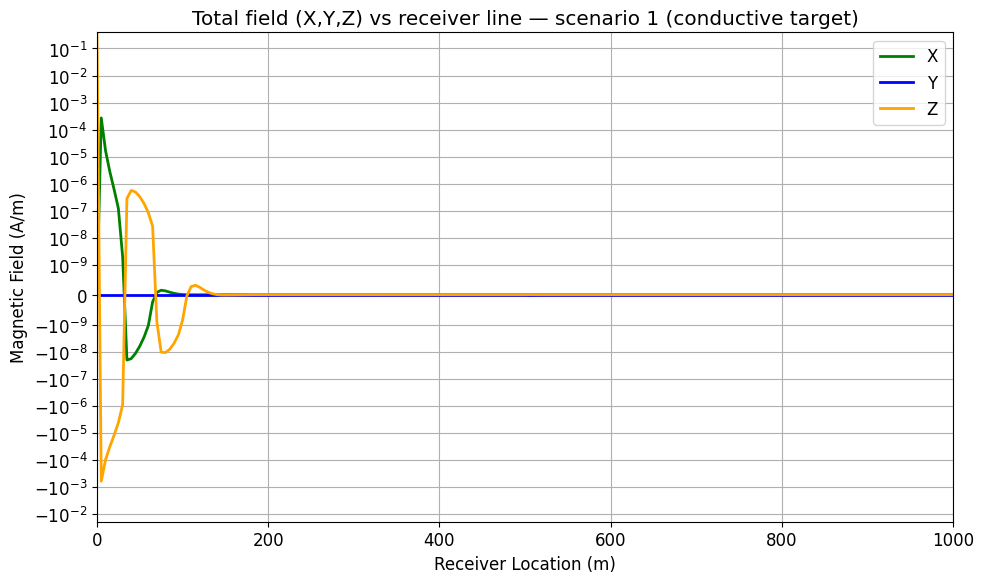

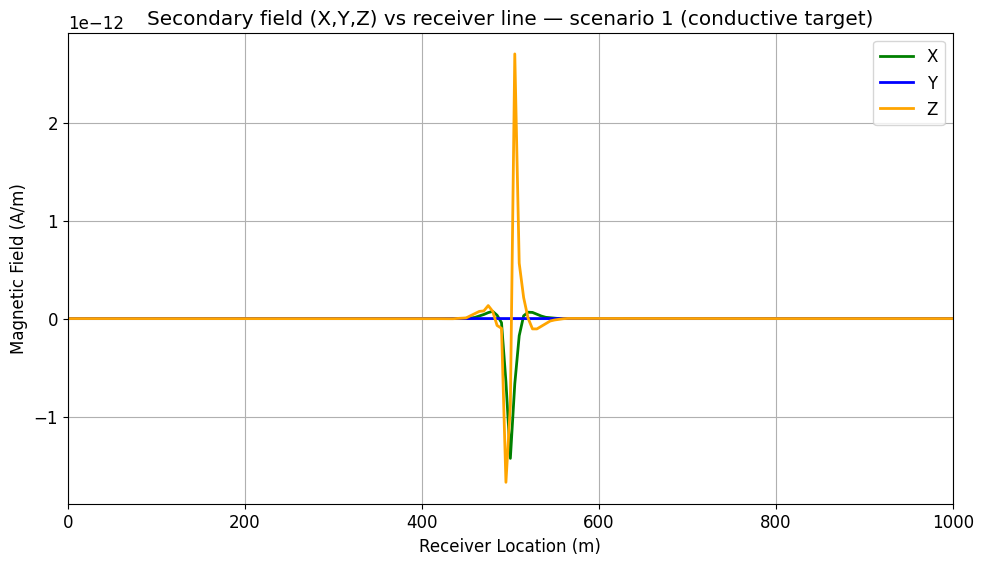

In [11]:
plot_total('conductive', 'scenario 1 (conductive target)')
plot_secondary('conductive', 'scenario 1 (conductive target)')

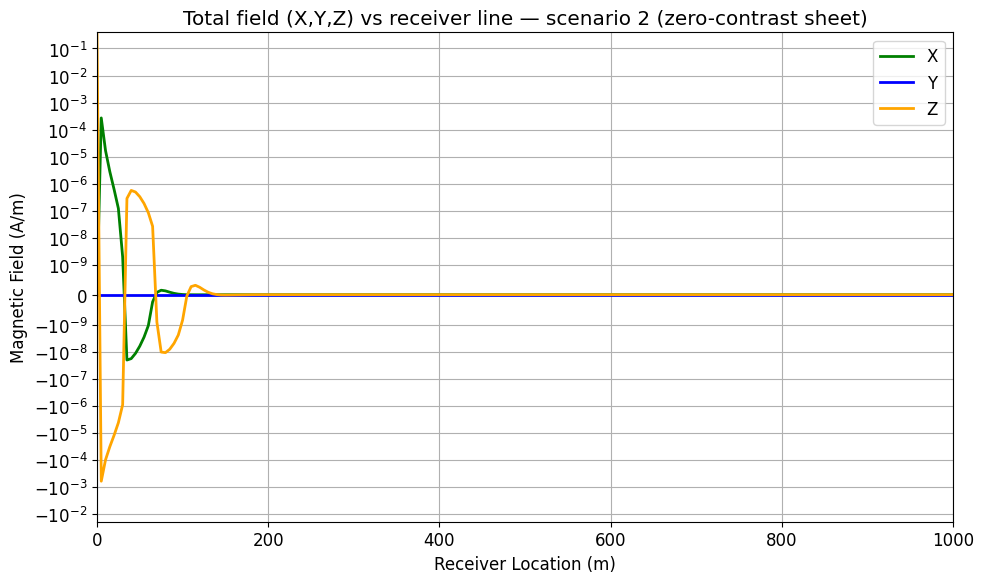

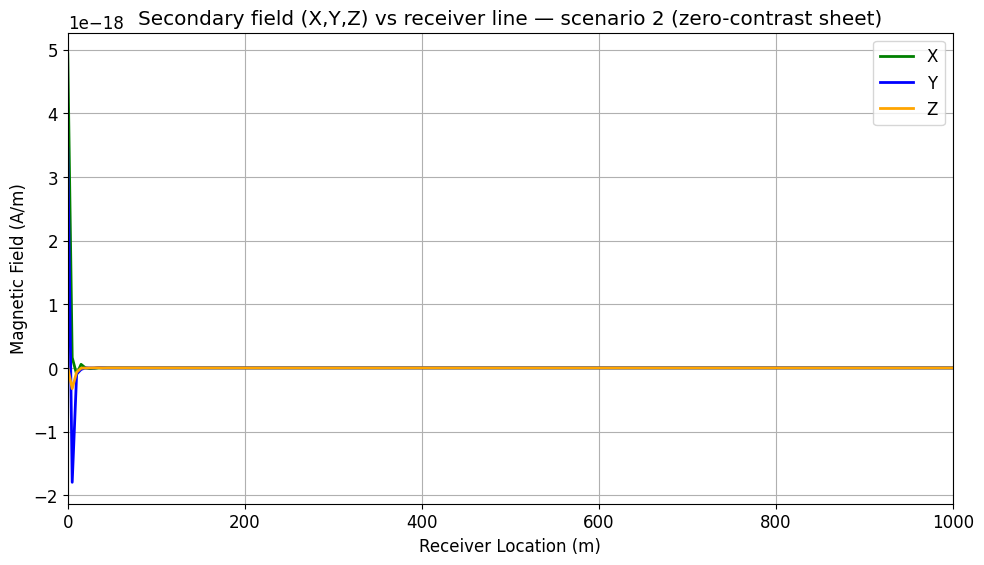

In [12]:
plot_total('zerocontrast', 'scenario 2 (zero-contrast sheet)')
plot_secondary('zerocontrast', 'scenario 2 (zero-contrast sheet)')

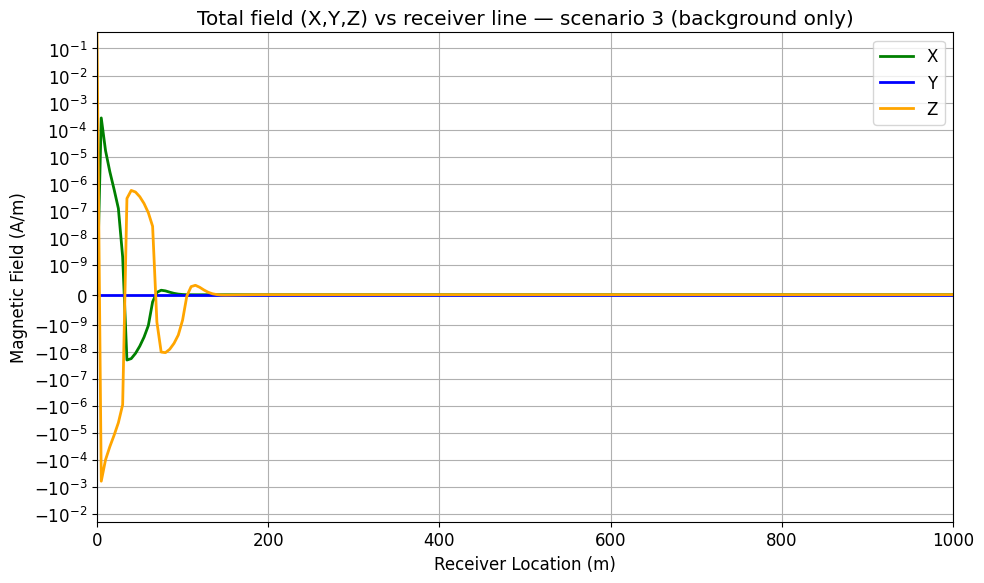

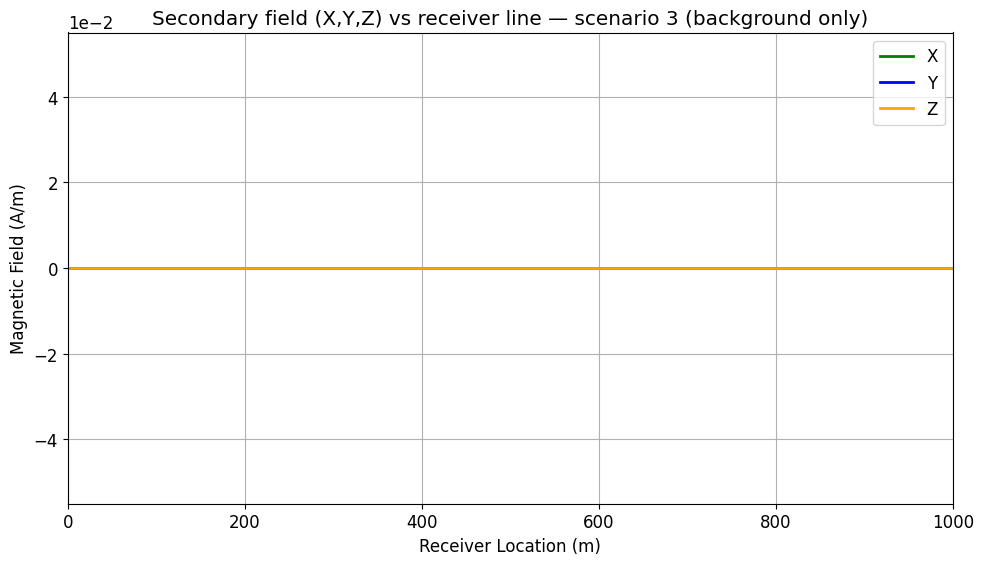

In [13]:
plot_total('background', 'scenario 3 (background only)')
plot_secondary('background', 'scenario 3 (background only)')